```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [279]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
from scipy.stats.mstats import gmean
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

from typing import List, Tuple

from timex.ecg import extractor, dataset
import matplotlib.pyplot as plt

import warnings
from neurokit2.misc import NeuroKitWarning
warnings.filterwarnings("ignore", category=NeuroKitWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
dotenv.load_dotenv('../.env')

In [255]:
BASE_DIR = os.getenv('ECG_DIR')
DS_DIR = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
HEA_DIR = os.path.join(BASE_DIR,
                       DS_DIR,
                       'records500',
                       '00000')

SAMPLE_RATE = 500


In [229]:
BASE_DIR

'T:\\laupodteam\\AIOS\\Bram\\data\\ECG'

In [230]:
HEA_DIR

'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000'

In [ ]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [208]:
ecg_path = r'T:\laupodteam\AIOS\Bram\data\ECG\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records500\00000\00001_hr' # hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
record = wfdb.rdrecord(ecg_path)
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [211]:
record.to_dataframe()

,I,II,III,AVR,AVL,AVF,V1,V2,V3,V4,V5,V6
0 days 00:00:00,-0.115,-0.050,0.065,0.082,-0.090,0.007,-0.065,-0.040,-0.005,-0.035,-0.035,-0.075
0 days 00:00:00.002000,-0.115,-0.050,0.065,0.082,-0.090,0.007,-0.065,-0.040,-0.005,-0.035,-0.035,-0.075
0 days 00:00:00.004000,-0.115,-0.050,0.065,0.082,-0.090,0.007,-0.065,-0.040,-0.005,-0.035,-0.035,-0.075
0 days 00:00:00.006000,-0.115,-0.050,0.065,0.082,-0.090,0.007,-0.065,-0.040,-0.005,-0.035,-0.035,-0.075
0 days 00:00:00.008000,-0.115,-0.050,0.065,0.082,-0.090,0.007,-0.065,-0.040,-0.005,-0.035,-0.035,-0.075
...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:00:09.990000,0.210,0.205,-0.005,-0.207,0.107,0.100,0.075,0.225,0.175,0.185,0.170,0.180
0 days 00:00:09.992000,0.210,0.205,-0.005,-0.207,0.107,0.100,0.075,0.225,0.175,0.185,0.170,0.180
0 days 00:00:09.994000,0.210,0.205,-0.005,-0.207,0.107,0.100,0.075,0.225,0.175,0.185,0.170,0.180
0 days 00:00:09.996000,0.210,0.205,-0.005,-0.207,0.107,0.100,0.075,0.225,0.175,0.185,0.170,0.180


In [ ]:
record.__dict__['comments'], meta_str

In [ ]:
wfdb.rdrecord(ecg_path).fs

In [ ]:
tmp = wfdb.rdsamp(ecg_path)[0]
tdf = pd.DataFrame(tmp, columns=band_names)

In [ ]:
band_names

In [ ]:
BAND = 'II'

In [ ]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

In [ ]:
filtered_signal = nk.signal_filter(tdf[BAND], sampling_rate=SAMPLE_RATE, lowcut=0.5, highcut=40, order=2)
plt.plot(filtered_signal)
plt.plot(tdf[BAND])

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [ ]:
peaks, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, 
                                 show=False).to_dict(orient='index')[0]

peak_features_nonlinear = nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'], 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False).to_dict(orient='index')[0]

peak_features_frequency = nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True).to_dict(orient='index')[0]
                                        

In [287]:
signals, _ = nk.ecg_process(cleaned_signal, sampling_rate=500)
hr_features = nk.ecg_intervalrelated(signals)
hr_features = {k: np.array(v).flatten()[0] for k,v in hr_features.to_dict(orient='index')[0].items()}
analyze_ecg = nk.ecg_analyze(signals, sampling_rate=500)

In [288]:
analyze_ecg = nk.ecg_analyze(signals, sampling_rate=500)
analyze_ecg = {k: np.array(v).flatten()[0] for k,v in analyze_ecg.to_dict(orient='index')[0].items()}

In [291]:
analyze_ecg.keys()

dict_keys(['ECG_Rate_Mean', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn', 'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Pe

In [290]:
hr_features

{'ECG_Rate_Mean': np.float64(63.91932091019351),
 'HRV_MeanNN': np.float64(469.8888888888889),
 'HRV_SDNN': np.float64(8.852181149926333),
 'HRV_SDANN1': np.float64(nan),
 'HRV_SDNNI1': np.float64(nan),
 'HRV_SDANN2': np.float64(nan),
 'HRV_SDNNI2': np.float64(nan),
 'HRV_SDANN5': np.float64(nan),
 'HRV_SDNNI5': np.float64(nan),
 'HRV_RMSSD': np.float64(11.645814698852115),
 'HRV_SDSD': np.float64(12.240885822287769),
 'HRV_CVNN': np.float64(0.01883888161488224),
 'HRV_CVSD': np.float64(0.02478418829266234),
 'HRV_MedianNN': np.float64(471.0),
 'HRV_MadNN': np.float64(10.3782),
 'HRV_MCVNN': np.float64(0.022034394904458597),
 'HRV_IQRNN': np.float64(12.0),
 'HRV_SDRMSSD': np.float64(0.7601169500660919),
 'HRV_Prc20NN': np.float64(463.2),
 'HRV_Prc80NN': np.float64(478.0),
 'HRV_pNN50': np.float64(0.0),
 'HRV_pNN20': np.float64(11.11111111111111),
 'HRV_MinNN': np.float64(456.0),
 'HRV_MaxNN': np.float64(482.0),
 'HRV_HTI': np.float64(3.0),
 'HRV_TINN': np.float64(0.0),
 'HRV_ULF': np.f

In [ ]:
len(hr_features), len(peak_features_time), len(peak_features_nonlinear), len(peak_features_frequency)

In [ ]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="cwt",
                                 show=True,
                                 show_type='all')

In [ ]:
waves_peak

In [ ]:
def find_flat_regions(ts: np.ndarray, flatten_order=20, mean='geometric')-> List[Tuple[int,int]]:
    """
        given a timeseries, find the flat regions, indicated with index-tuples
    """

    ddlist = []
    for k in range(1,flatten_order+1):
        ddlist.append(np.diff(ts, k, append=[np.nan]*k))
    stacked = np.vstack(ddlist)
    if mean=='arithmetic':
        _mean = np.nanmean(stacked[:,:-flatten_order], axis=0)
    elif mean=='geometric':
        _mean = gmean(np.abs(stacked[:,:-flatten_order]), axis=0, nan_policy='omit')
    
    return np.convolve(_mean, np.ones(flatten_order-1), mode='same')

In [ ]:
def convolve_channels(ts: np.ndarray, ts2: np.ndarray):    
    return np.convolve(ts, ts2, mode='same')

In [ ]:
cleaned_signals = [nk.ecg_clean(tdf[d], sampling_rate=SAMPLE_RATE) for d in band_names]

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(cleaned_signal);

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(find_flat_regions(cleaned_signal, flatten_order=7, mean='arithmetic'));

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(np.sum(np.vstack(cleaned_signals), axis=0))

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(convolve_channels(cleaned_signals[0], cleaned_signals[11]))

In [ ]:
waves_peak.keys()

In [ ]:
## Durations 
#############
PtP = np.diff(waves_peak['ECG_P_Peaks'])/SAMPLE_RATE
Pduration = np.subtract(waves_peak['ECG_P_Offsets'], waves_peak['ECG_P_Onsets'])/SAMPLE_RATE

QtQ = np.diff(waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE

RtRon = np.diff(waves_peak['ECG_R_Onsets'])/SAMPLE_RATE
RtRoff = np.diff(waves_peak['ECG_R_Offsets'])/SAMPLE_RATE
Rduration = np.subtract(waves_peak['ECG_R_Offsets'], waves_peak['ECG_R_Onsets'])/SAMPLE_RATE

StS = np.diff(waves_peak['ECG_S_Peaks'])/SAMPLE_RATE

TtT = np.diff(waves_peak['ECG_T_Peaks'])/SAMPLE_RATE
Tduration = np.subtract(waves_peak['ECG_T_Offsets'], waves_peak['ECG_T_Onsets'])/SAMPLE_RATE

QRSduration = np.subtract(waves_peak['ECG_S_Peaks'], waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE
PQtime = np.subtract(waves_peak['ECG_Q_Peaks'], waves_peak['ECG_P_Peaks'])/SAMPLE_RATE
QTtime = np.subtract(waves_peak['ECG_T_Offsets'], waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE

## Elevations and depressions
###############
ECG_S_Peaks = np.array(waves_peak['ECG_R_Offsets'])
ECG_S_Peaks= ECG_S_Peaks[~np.isnan(ECG_S_Peaks)].astype(int)
    
S_peak_mean = np.mean(cleaned_signal[ECG_S_Peaks])
S_peak_std = np.std(cleaned_signal[ECG_S_Peaks])

ECG_R_Offsets = np.array(waves_peak['ECG_R_Offsets'])
ECG_R_Offsets= ECG_R_Offsets[~np.isnan(ECG_R_Offsets)].astype(int)
                         
R_offset_mean = np.mean(cleaned_signal[ECG_R_Offsets])
R_offset_std = np.std(cleaned_signal[ECG_R_Offsets])

ECG_T_Onsets = np.array(waves_peak['ECG_T_Onsets'])
ECG_T_Onsets= ECG_T_Onsets[~np.isnan(ECG_T_Onsets)].astype(int)
       
T_onset_mean = np.mean(cleaned_signal[ECG_T_Onsets])
T_onset_std = np.std(cleaned_signal[ECG_T_Onsets])

st_ranges = zip(waves_peak['ECG_S_Peaks'], waves_peak['ECG_T_Onsets'])
st_ranges = [(b, e) for b,e in st_ranges]

# STdepression
# STelevation
# T_wave_inversion

In [ ]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

#ecg_rsp = nk.ecg_rsp(ecg_rates, method='sarkar2015', sampling_rate=SAMPLE_RATE)

In [ ]:
np.mean(ecg_rates), np.std(ecg_rates), np.mean(quality_score)

In [ ]:
ecg_rates.shape, ecg_rsp.shape, cleaned_signal.shape

In [ ]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=True)

In [ ]:
ecg_segmentation.keys()

In [ ]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
from timex.ecg import dataset

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

In [354]:
ecgDS = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                        DS_DIR,
                                        'records500'),
                       label_binarizer=None,
                       augmentations=[],
                       pretrain= False,
                       encode=False,
                       preprocessing=['savgol', 'bandpass', 'notch'])

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [ ]:
res_dict = defaultdict(dict)
for i in tqdm(range(len(ecgDS))):
    r = ecgDS[i]
    res_dict[r[2]]={
        'signal': r[0],
        'label': r[1],
        'fs': 500
    }
    res_dict[r[2]].update(r[4])

  4%|▍         | 836/21799 [00:54<16:02, 21.78it/s]

In [ ]:
ecgExtractor = extractor.ECGxtract(sampling_rate=500, 
                             sanity_check=True,
                             extractor_groups=['wavelets', 'fcc', 'ecgspecific'], 
                             extractor_type='catch22')

In [ ]:
extractions = ecgExtractor.extract_from_dict(res_dict, SignalCol='signal', FsCol='fs')

100%|██████████| 987/987 [01:23<00:00, 11.75it/s]


In [ ]:
len(extractions.keys())

987

In [ ]:
extractions_df = pd.DataFrame(extractions).T

In [ ]:
extractions_df.index = [f"records500{''.join(idx.split('records500')[-1])}"
                         for idx in extractions_df.index]

extractions_df.index = [idx.replace('\\', '/').replace('.hea','')
                         for idx in extractions_df.index]

In [ ]:
#dx_map = pd.read_csv(os.path.join(BASE_DIR, 'physionet_classification_challenge', 'Dx_map.csv'))
ptbxl_meta = pd.read_csv(os.path.join(BASE_DIR, DS_DIR, 'ptbxl_database.csv'), sep=',')

In [ ]:
ptbxl_meta = ptbxl_meta[['filename_hr', 'age', 'sex', 'weight', 'nurse', 
                         'infarction_stadium1', 'infarction_stadium2', 'scp_codes', 'pacemaker']]
ptbxl_meta['filename_hr'] = ptbxl_meta['filename_hr'].str.strip()
ptbxl_meta = ptbxl_meta.set_index('filename_hr')


Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')

In [ ]:
print(extractions_df.shape)
extractions_df = extractions_df.dropna(how='all')
print(extractions_df.shape)

(987, 1215)
(987, 1215)


Text(0.5, 1.0, 'Number of NaN per sample')

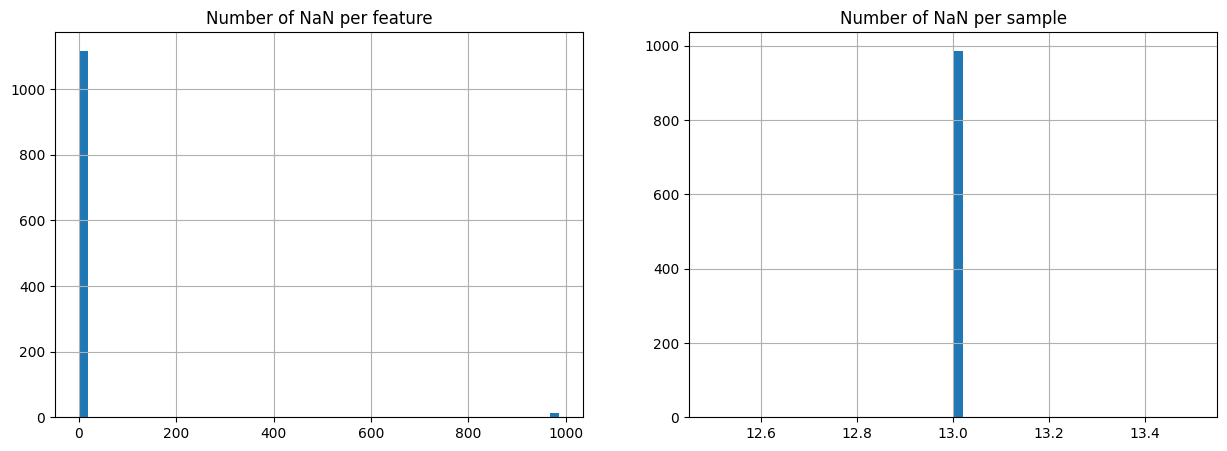

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
extractions_df.isna().sum(axis=0).hist(bins=50, ax=ax[0])
extractions_df.isna().sum(axis=1).hist(bins=50, ax=ax[1])

ax[0].set_title('Number of NaN per feature')
ax[1].set_title('Number of NaN per sample')

In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from umap import UMAP

In [ ]:
# add label and demographics
# extractions_df['label'] = None
# for k in _keys:
#     extractions_df.loc[k, 'label'] = res_dict[k]['label']

In [ ]:
VAL_COLS = [c for c in extractions_df.columns if c not in ['label', 'segment', 'fs']]

In [ ]:
# extractions_df.to_parquet(os.path.join(BASE_DIR, 
#                                        'physionet_classification_challenge', 
#                                        'extractions_wavelets.parquet'))

# extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
#                                                'physionet_classification_challenge', 
#                                                'extractions_wavelets.parquet'))

extractions_df.to_parquet(os.path.join(BASE_DIR, 
                                       DS_DIR, 
                                       'extractions_wavelets.parquet'))

# extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
#                                                'physionet_classification_challenge', 
#                                                'extractions_wavelets.parquet'))

In [ ]:
le_pipe_euc = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', IterativeImputer(n_nearest_features=20)),
    ('umap', UMAP(n_neighbors=25, min_dist=0.0, metric='manhattan', n_components=3))
], verbose=True)

In [ ]:
extractions_2d = le_pipe_euc.fit_transform(extractions_df[VAL_COLS].values)

[Pipeline] ............ (step 1 of 3) Processing scaler, total=   0.0s
[Pipeline] ........... (step 2 of 3) Processing imputer, total=   6.7s
[Pipeline] .............. (step 3 of 3) Processing umap, total=   2.1s


In [ ]:
extractions_2d_df = pd.DataFrame(extractions_2d, columns=['d1', 'd2', 'd3'])
extractions_2d_df.index = extractions_df.index
extractions_2d_df = extractions_2d_df.join(ptbxl_meta)
#extractions_2d_df['label'] = extractions_df['label'].values

In [ ]:
extractions_2d_df.loc[extractions_2d_df.age>100, 'age'] = extractions_2d_df.loc[extractions_2d_df.age>100, 'age']/10

In [ ]:
# collected_labels = [ls.split(",") for ls in extractions_2d_df['label'].unique()]
# label_set = set()
# for ls in collected_labels:
#     for l in ls:
#         label_set.add(l.strip())

# extractions_2d_df[list(label_set)] = False

# extractions_2d_df.loc[:, list(label_set)] = \
#     np.vstack(extractions_2d_df['label'].apply(lambda x: get_label_bool(x)).tolist())

# dx_map[dx_map['Dx'].str.contains('cardia', case=False, na=False)].head(10)
# dx_map['SNOMED CT Code'] = dx_map['SNOMED CT Code'].astype(str)
# dx_map[dx_map['SNOMED CT Code']=='164934002']

In [ ]:
def get_label_bool(x):
    bool_list = []
    for label in list(label_set):
        if label in x:
            bool_list.append(True)
        else:
            bool_list.append(False)
    return np.array(bool_list)

In [ ]:
dkeys = set()
code_list = []
for ind, str_d in zip(extractions_2d_df.index, extractions_2d_df['scp_codes'].values):
    d = eval(str_d)
    code_list.append({'index': ind, 'CodeDict': d})
    for k in d.keys():
        dkeys.add(k)

new_list = []
for r in code_list:
    r_l = []
    for k in list(dkeys):
        r_l.append(r['CodeDict'].get(k, np.nan))
    new_list.append(r_l)

extractions_2d_df[[f'DIAG_{k}' for k in list(dkeys)]] = new_list

In [ ]:
extractions_2d_df[[f'DIAG_{k}' for k in list(dkeys)]].notna().mean().sort_values()

DIAG_1AVB     0.027356
DIAG_3AVB     0.001013
DIAG_ABQRS    0.028369
DIAG_AFIB     0.049645
DIAG_AFLT     0.010132
                ...   
DIAG_STD_     0.075988
DIAG_SVTAC    0.001013
DIAG_TAB_     0.001013
DIAG_TRIGU    0.001013
DIAG_VCLVH    0.022290
Length: 63, dtype: float64

<Figure size 1500x1000 with 0 Axes>

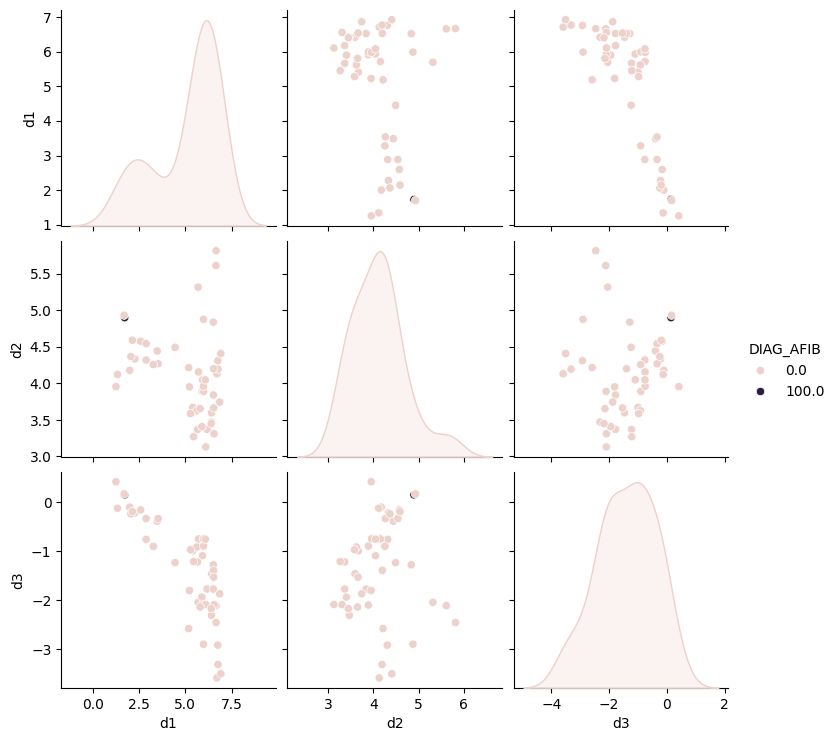

In [ ]:
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.pairplot(data=extractions_2d_df, x_vars=['d1', 'd2', 'd3'], y_vars=['d1', 'd2', 'd3'],
              hue='DIAG_AFIB')

In [ ]:
if self.ecg_debug:
    signals, info = nk.ecg_process(signal, sampling_rate=self.sampling_rate)
    nk.ecg_plot(signals, info)